In [37]:
#load libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

In [38]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [39]:
# data info
print(df.shape)

print(df.columns)

print(df.info())

(2640, 12)
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-nul

In [40]:
# checking missing values
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [41]:
# remove duplicates
df.drop_duplicates(inplace=True)

print(df.shape)

(2640, 12)


In [42]:
#statistical summmary
print(df.describe())

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

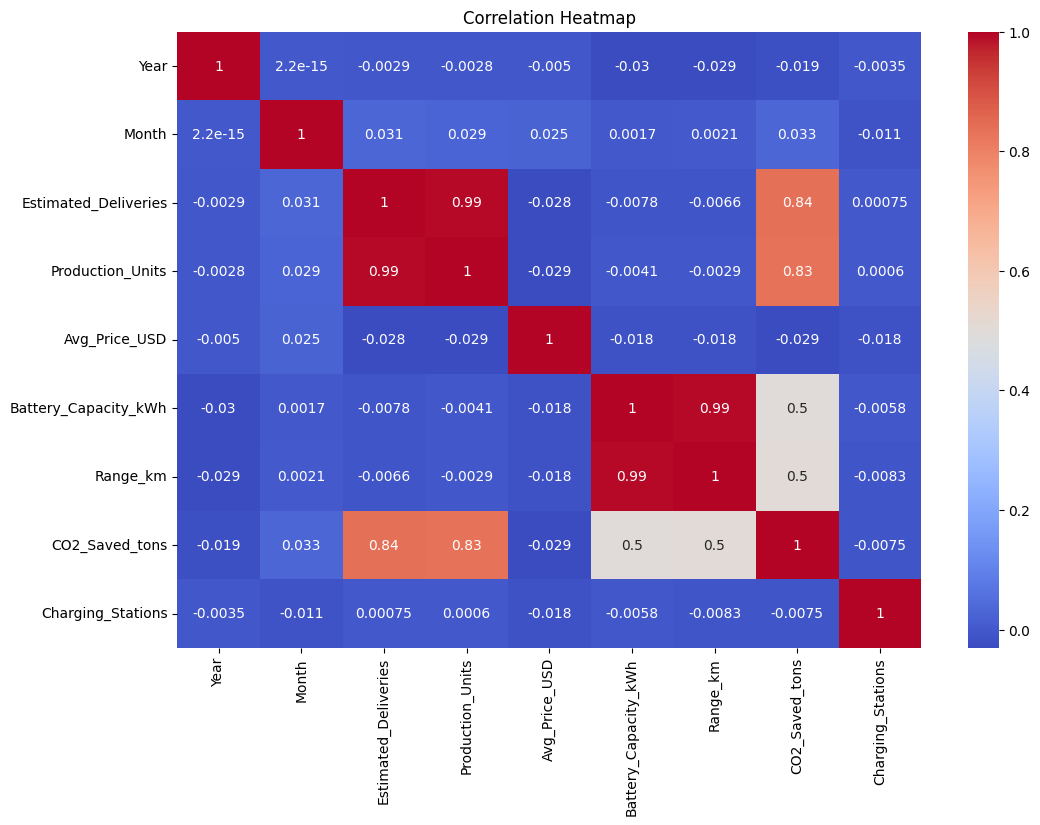

In [43]:
# heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

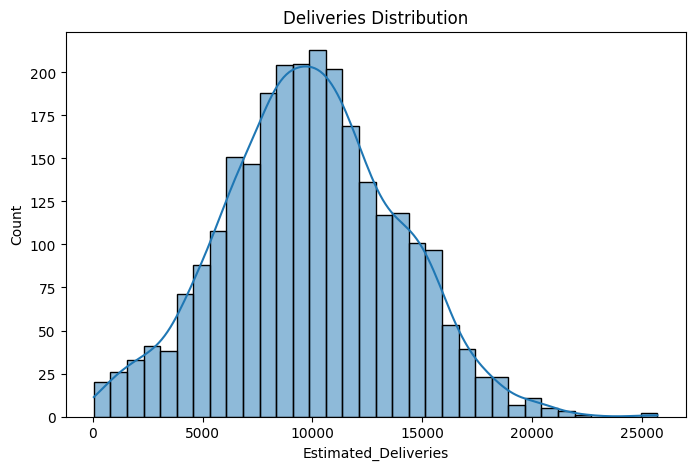

In [44]:
# Distribution plot
plt.figure(figsize=(8,5))

sns.histplot(df['Estimated_Deliveries'],
             kde=True)

plt.title("Deliveries Distribution")

plt.show()

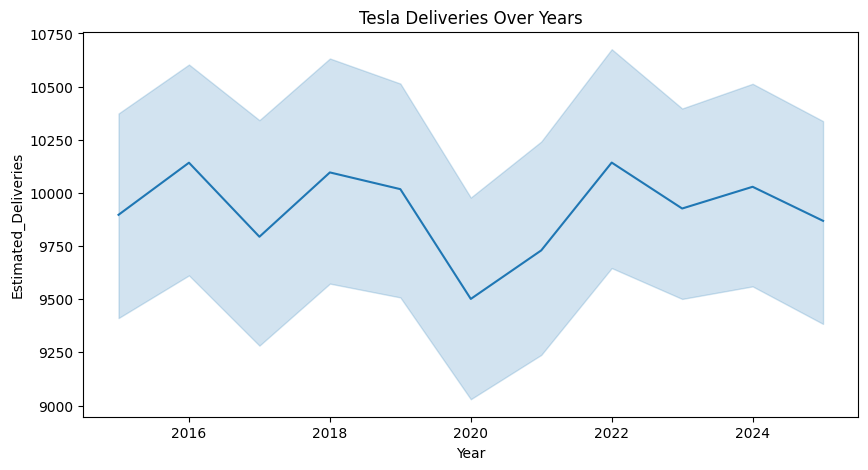

In [45]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x='Year',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Tesla Deliveries Over Years")

plt.show()

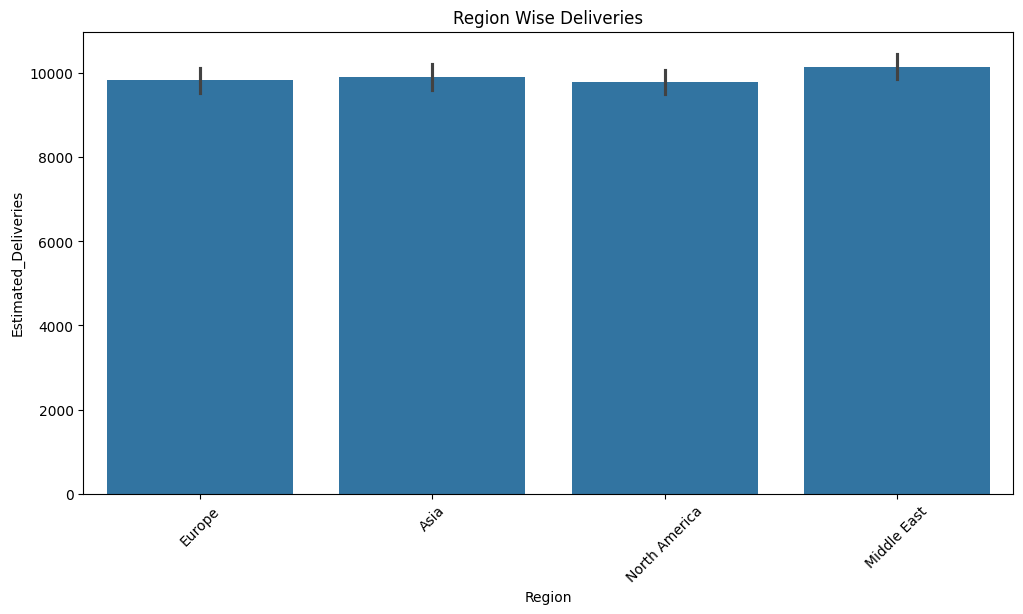

In [46]:
# Region over deliveries
plt.figure(figsize=(12,6))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title("Region Wise Deliveries")

plt.xticks(rotation=45)

plt.show()

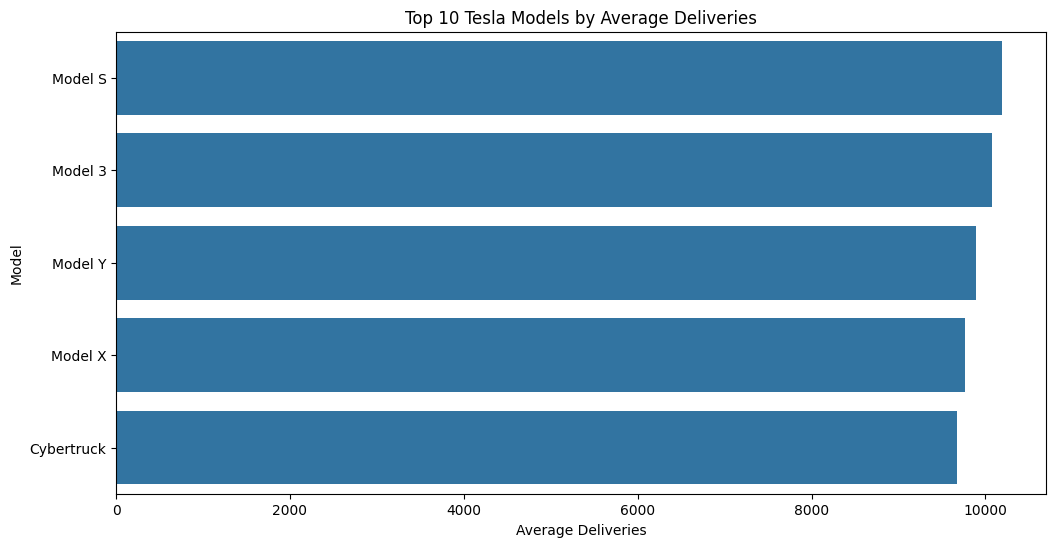

In [47]:
# Top Tesla Models by Average Deliveries

top_models = df.groupby("Model")["Estimated_Deliveries"] \
               .mean() \
               .sort_values(ascending=False) \
               .head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_models.values,
    y=top_models.index
)

plt.title("Top 10 Tesla Models by Average Deliveries")
plt.xlabel("Average Deliveries")
plt.ylabel("Model")

plt.show()

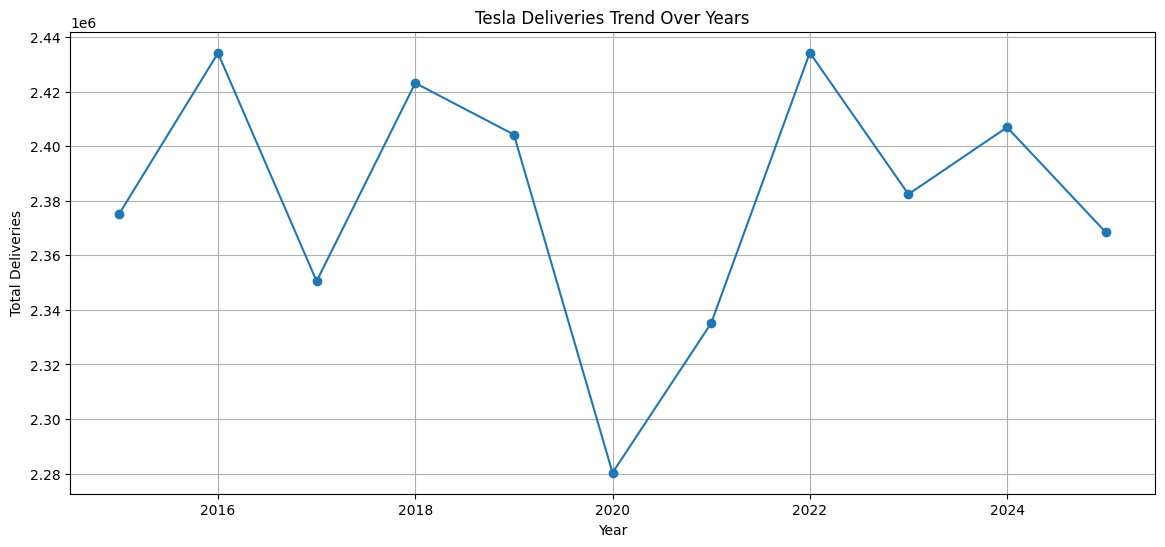

In [48]:
# deliveries trend over time
plt.figure(figsize=(14,6))

monthly_sales = df.groupby(["Year"])["Estimated_Deliveries"].sum()

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Tesla Deliveries Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")

plt.grid(True)

plt.show()

# Feature Enginneering

In [49]:
# Feature Engineering

df['Price_Per_km'] = (
    df['Avg_Price_USD'] /
    (df['Range_km'] + 1)
)

print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  Price_Per_km  
0         1863.42  Interpolated (Month)              12207    131.736553  
1          249.46    Official (Quarter)     

In [50]:
#Encode categorical values
label_encoder = LabelEncoder()

categorical_cols = ['Region', 'Model', 'Source_Type']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [51]:
X = df[
    [
        'Year',
        'Region',
        'Model',
        'Production_Units',
        'Avg_Price_USD',
        'Range_km',
        'Battery_Capacity_kWh'
    ]
]

y = df['Estimated_Deliveries']

In [52]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# LINEAR REGRESSION

In [53]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

In [54]:
print("LINEAR REGRESSION RESULTS")

print("MAE:",
      mean_absolute_error(y_test, linear_pred))

print("MSE:",
      mean_squared_error(y_test, linear_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, linear_pred)))

print("R2 Score:",
      r2_score(y_test, linear_pred))

LINEAR REGRESSION RESULTS
MAE: 339.9714031989552
MSE: 174124.60837760818
RMSE: 417.2824084209735
R2 Score: 0.9883187144368624


# Linear Regression, Ridge, and Lasso

In [55]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=10000))
    ])
}

ridge_params = {"model__alpha":[0.01,0.1,1,10,100]}
lasso_params = {"model__alpha":[0.001,0.01,0.1,1,10]}

ridge_grid = GridSearchCV(models["Ridge"], ridge_params, cv=5, scoring="r2")
lasso_grid = GridSearchCV(models["Lasso"], lasso_params, cv=5, scoring="r2")

models["Linear Regression"].fit(X_train, y_train)
ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)

lr_pred = models["Linear Regression"].predict(X_test)
ridge_pred = ridge_grid.predict(X_test)
lasso_pred = lasso_grid.predict(X_test)


In [56]:

comparison = pd.DataFrame({
    "Model":["Linear Regression","Ridge","Lasso"],
    "R2":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],
    "MAE":[
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ]
})

print("Best Ridge Alpha:", ridge_grid.best_params_)
print("Best Lasso Alpha:", lasso_grid.best_params_)
print(comparison.sort_values("R2", ascending=False))


Best Ridge Alpha: {'model__alpha': 1}
Best Lasso Alpha: {'model__alpha': 10}
               Model        R2         MAE        RMSE
2              Lasso  0.988395  339.168148  415.918525
0  Linear Regression  0.988319  339.971403  417.282408
1              Ridge  0.988313  340.135907  417.390991


# DECISION TREE REGRESSOR

In [57]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [58]:
print("DECISION TREE RESULTS")

print("MAE:",
      mean_absolute_error(y_test, dt_pred))

print("MSE:",
      mean_squared_error(y_test, dt_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, dt_pred)))

print("R2 Score:",
      r2_score(y_test, dt_pred))

DECISION TREE RESULTS
MAE: 494.58522727272725
MSE: 415563.8125
RMSE: 644.6423911751383
R2 Score: 0.9721215765608986


# RANDOM FOREST REGRESSOR

In [59]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [60]:
print("RANDOM FOREST RESULTS")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("MSE:",
      mean_squared_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))

RANDOM FOREST RESULTS
MAE: 368.3549474512659
MSE: 215671.12876662635
RMSE: 464.40405765521297
R2 Score: 0.9855315336165249


In [61]:
print("Train Score:",
      rf_model.score(X_train, y_train))

print("Test Score:",
      rf_model.score(X_test, y_test))

Train Score: 0.9967341697350128
Test Score: 0.9855315336165249


# HYPERPARAMETER TUNING

In [62]:
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42
    ),
    param_grid=params,
    cv=3,
    scoring='r2'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}


In [63]:
# BEST MODEL
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("TUNED RANDOM FOREST RESULTS")

print("R2 Score:",
      r2_score(y_test, best_pred))

TUNED RANDOM FOREST RESULTS
R2 Score: 0.9867179936509046


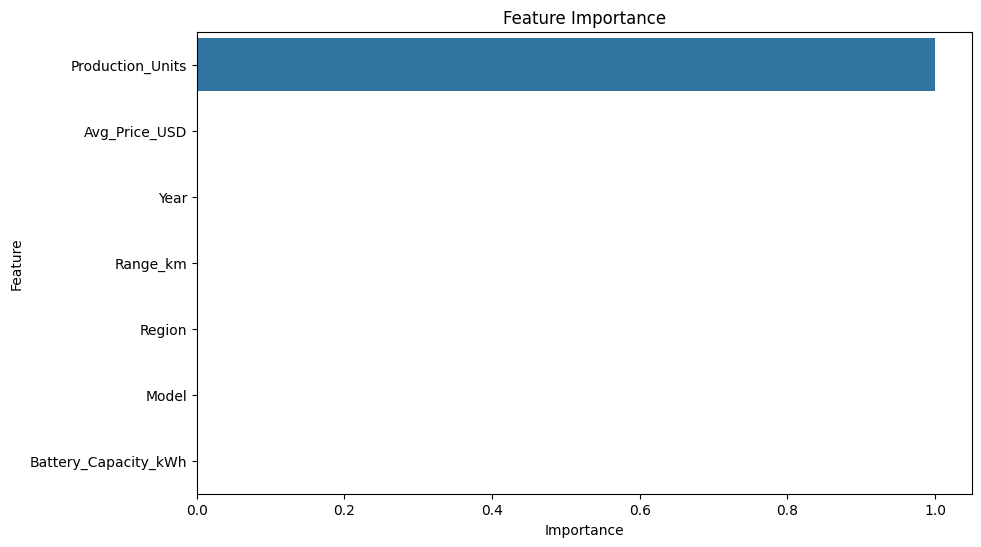

In [64]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

# TIME SERIES FORECASTING

In [65]:

ts_data = df['Estimated_Deliveries']

In [66]:
model = ARIMA(ts_data, order=(1,1,1))

result = model.fit()

In [67]:
# FORECAST FUTURE DELIVERIES
forecast = result.forecast(steps=12)

print("NEXT 12 FORECASTED VALUES")

print(forecast)

NEXT 12 FORECASTED VALUES
2640    10259.117363
2641     9903.048260
2642     9919.686482
2643     9918.909019
2644     9918.945348
2645     9918.943650
2646     9918.943730
2647     9918.943726
2648     9918.943726
2649     9918.943726
2650     9918.943726
2651     9918.943726
Name: predicted_mean, dtype: float64


# PLOT FOREST

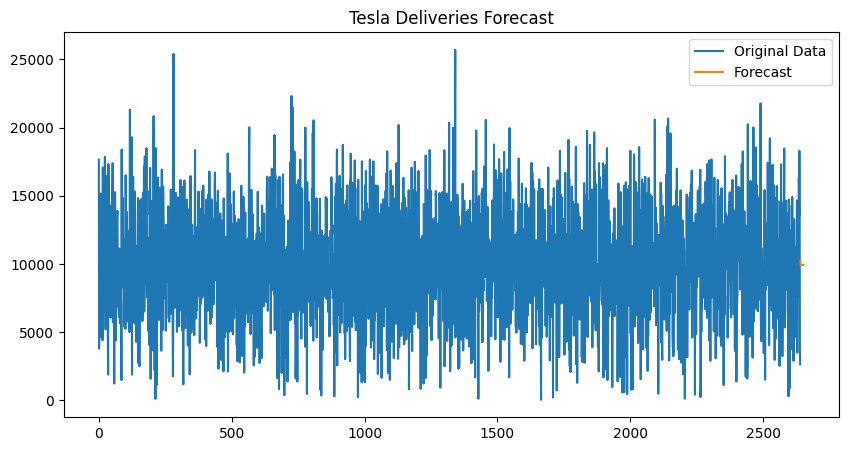

In [68]:
plt.figure(figsize=(10,5))

plt.plot(ts_data,
         label='Original Data')

plt.plot(
    range(len(ts_data),
    len(ts_data)+12),
    forecast,
    label='Forecast'
)

plt.legend()

plt.title("Tesla Deliveries Forecast")

plt.show()

# COMPARE ALL THE MODELS

In [69]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "R2": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, best_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, best_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, best_pred))
    ]
})

print(results.sort_values("R2", ascending=False))

                 Model        R2         MAE        RMSE
2                Lasso  0.988395  339.168148  415.918525
0    Linear Regression  0.988319  339.971403  417.282408
1                Ridge  0.988313  340.135907  417.390991
5  Tuned Random Forest  0.986718  359.160124  444.955519
4        Random Forest  0.985532  368.354947  464.404058
3        Decision Tree  0.972122  494.585227  644.642391


368.3549474512659


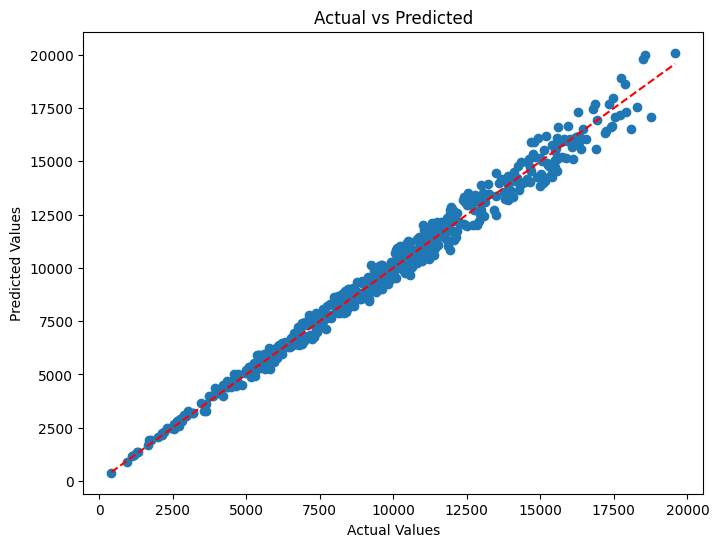

In [70]:
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test, rf_pred))

# graph
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()